# 집값 예측 프로젝트

목표: 집의 여러 조건을 가지고 가격(price)을 예측하는 회귀 모델 만들기  
평가 지표: RMSE (Root Mean Squared Error) 11만 이하

## 1. 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# 그래프 기본 설정
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# 데이터 불러오기
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')

print('train:', train.shape)
print('test:', test.shape)
print('sub:', sub.shape)

train: (15035, 21)
test: (6555, 20)
sub: (6468, 2)


### 라이브러리를 불러오고 데이터를 읽어들이는 셀  
### pandas는 표 형태 데이터 처리, numpy는 수치 연산, matplotlib, seaborn 은 시각화에 사용
### sklearn 에서는 데이터 분할, 스케일링, 각종 모델, 평가 지표를 가져옴
### train.csv, test.csv, sample_submission.csv 세 파일을 읽어서 각각의 shape을 출력해 데이터 규모를 먼저 파악

## 2. EDA (탐색적 데이터 분석)

In [2]:
# 기본 정보 확인
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


### head()로 데이터 앞 5행을 출력해 컬럼 이름과 실제 값 형태를 눈으로 확인 
### id, date, price, bedrooms 같은 컬럼이 어떤 타입과 값 범위로 들어오는지 처음 파악하는 단계

In [3]:
# 기술통계
train.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,15035.000000,1.503500e+04,15035.000000,15035.000000,15035.000000,1.503500e+04,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000
mean,7517.000000,5.406827e+05,3.369139,2.115065,2083.790223,1.529697e+04,1.498071,0.007117,0.234253,3.406651,7.660725,1794.158164,289.632059,1971.100432,83.798936,98078.031726,47.560721,-122.213677,1992.754772,12823.884935
std,4340.374984,3.715247e+05,0.902721,0.767519,922.134087,4.261282e+04,0.538522,0.084063,0.763376,0.646505,1.179803,831.738609,440.663284,29.407612,400.398498,53.297815,0.138164,0.141294,691.456442,27736.259787
min,0.000000,7.800000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3758.500000,3.220000e+05,3.000000,1.750000,1430.000000,5.027500e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.472700,-122.328000,1490.000000,5100.000000
50%,7517.000000,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1570.000000,0.000000,1975.000000,0.000000,98065.000000,47.571900,-122.231000,1850.000000,7610.000000
75%,11275.500000,6.450000e+05,4.000000,2.500000,2560.000000,1.069550e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2230.000000,550.000000,1997.000000,0.000000,98117.000000,47.678300,-122.126000,2360.000000,10076.000000
max,15034.000000,7.700000e+06,10.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4130.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### describe()는 각 숫자형 컬럼의 count, 평균, 표준편차, 최솟값, 사분위수, 최댓값을 한 번에 보여줌  
### 값 범위가 비정상적으로 넓거나, 최솟값이 음수인 컬럼이 있는지 여기서 잡아냄

In [4]:
train.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

### isnull().sum()으로 컬럼별 결측치 개수를 확인  
### 0이 나오면 결측치가 없다는 뜻이고, 그러면 별도 처리 없이 바로 다음 단계로 ㄱㄱ

# 결측치 분석 결과

모든 컬럼에 결측치가 없는 것으로 확인됨. 별도의 결측치 처리 작업 없이 바로 전처리 단계로 진행 가능하다.

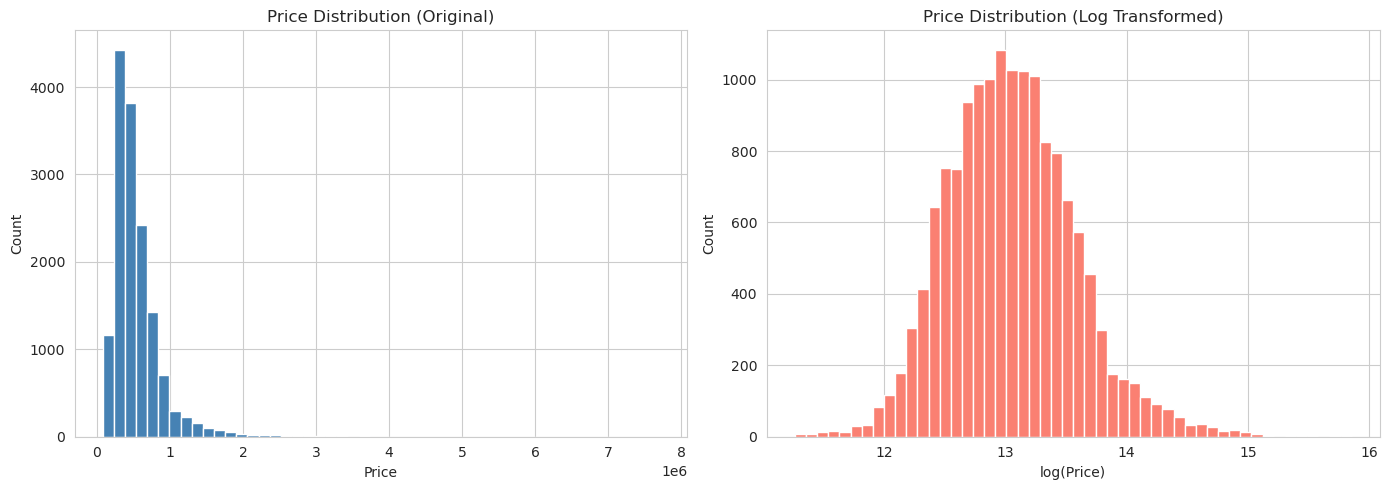

In [5]:
# price 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(train['price']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## price의 원본 분포와 로그 변환 후 분포를 나란히 그림  
## 원본은 오른쪽으로 길게 꼬리가 뻗는 우편향 분포, np.log1p()를 씌우면 좌우 대칭에 가까운 형태가 됨  
## 이 차이가 나중에 로그 타겟을 쓰는 근거가 됨.

# Price 분포 분석

원래 price 분포는 오른쪽으로 심하게 치우쳐 있음(Right-skewed). 로그 변환 후엔 정규분포에 가까워지는 걸 확인할 수 있음. 이는 향후 모델링 시 log1p(price)를 타겟으로 쓰면 성능 향상에 도움이 될 수 있다는 힌트다.

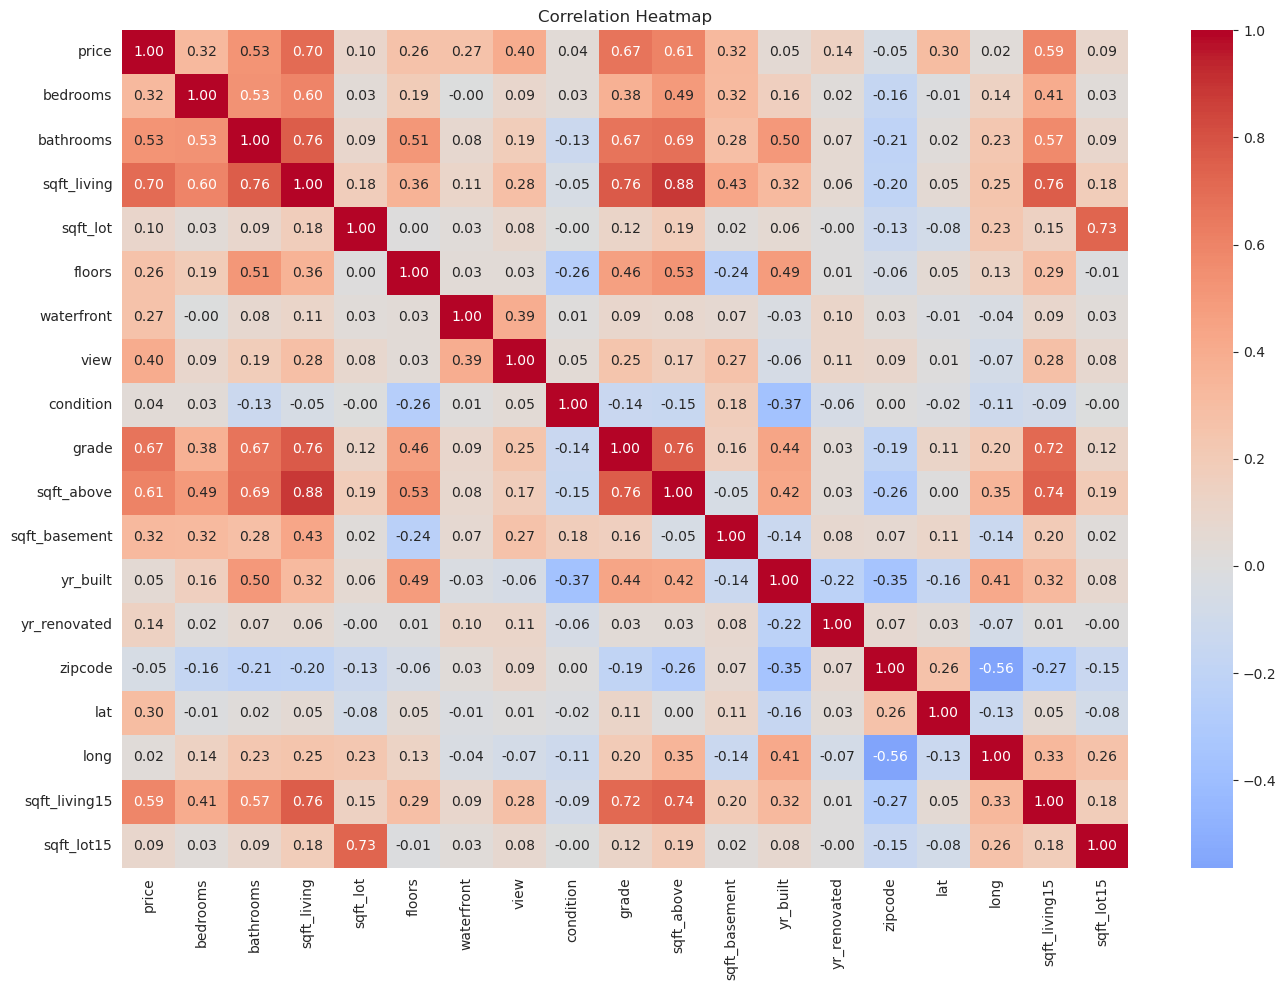

In [6]:
# 수치형 변수들과 price 상관관계
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'id']

corr = train[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 히트맵으로 모든 수치형 변수 간 상관계수를 한눈에 봄  
### coolwarm 색상에서 빨간색일수록 양의 상관, 파란색일수록 음의 상관임  
### price 행과 열을 보면 어떤 변수가 집값과 가장 관련이 깊은지 파악할 가능

In [7]:
# price와 각 변수 상관계수 내림차순 확인
corr_price = corr['price'].sort_values(ascending=False)
print(corr_price)

price            1.000000
sqft_living      0.702899
grade            0.667211
sqft_above       0.608577
sqft_living15    0.586419
bathrooms        0.525479
view             0.400806
bedrooms         0.323672
sqft_basement    0.322218
lat              0.301604
waterfront       0.265738
floors           0.262588
yr_renovated     0.140808
sqft_lot         0.096793
sqft_lot15       0.086384
yr_built         0.047290
condition        0.039740
long             0.023547
zipcode         -0.051498
Name: price, dtype: float64


### corr['price']를 내림차순으로 정렬해서 price와 가장 상관관계가 높은 변수 순서를 텍스트로 확인  
### 히트맵은 시각적으로 보기 좋지만 정확한 수치가 필요할 땐 이렇게 출력하는 게 편함

## 상관관계 분석 결과

- sqft_living (0.70), grade (0.67), sqft_above (0.61) 순으로 price와 높은 상관관계
- lat(위도)도 상관계수가 높은 편 → 위치 정보가 집값에 중요한 영향
- sqft_living과 sqft_above는 서로 높은 상관관계 → 다중공선성 주의 필요
- yr_built와 condition은 price와 상관관계가 낮음

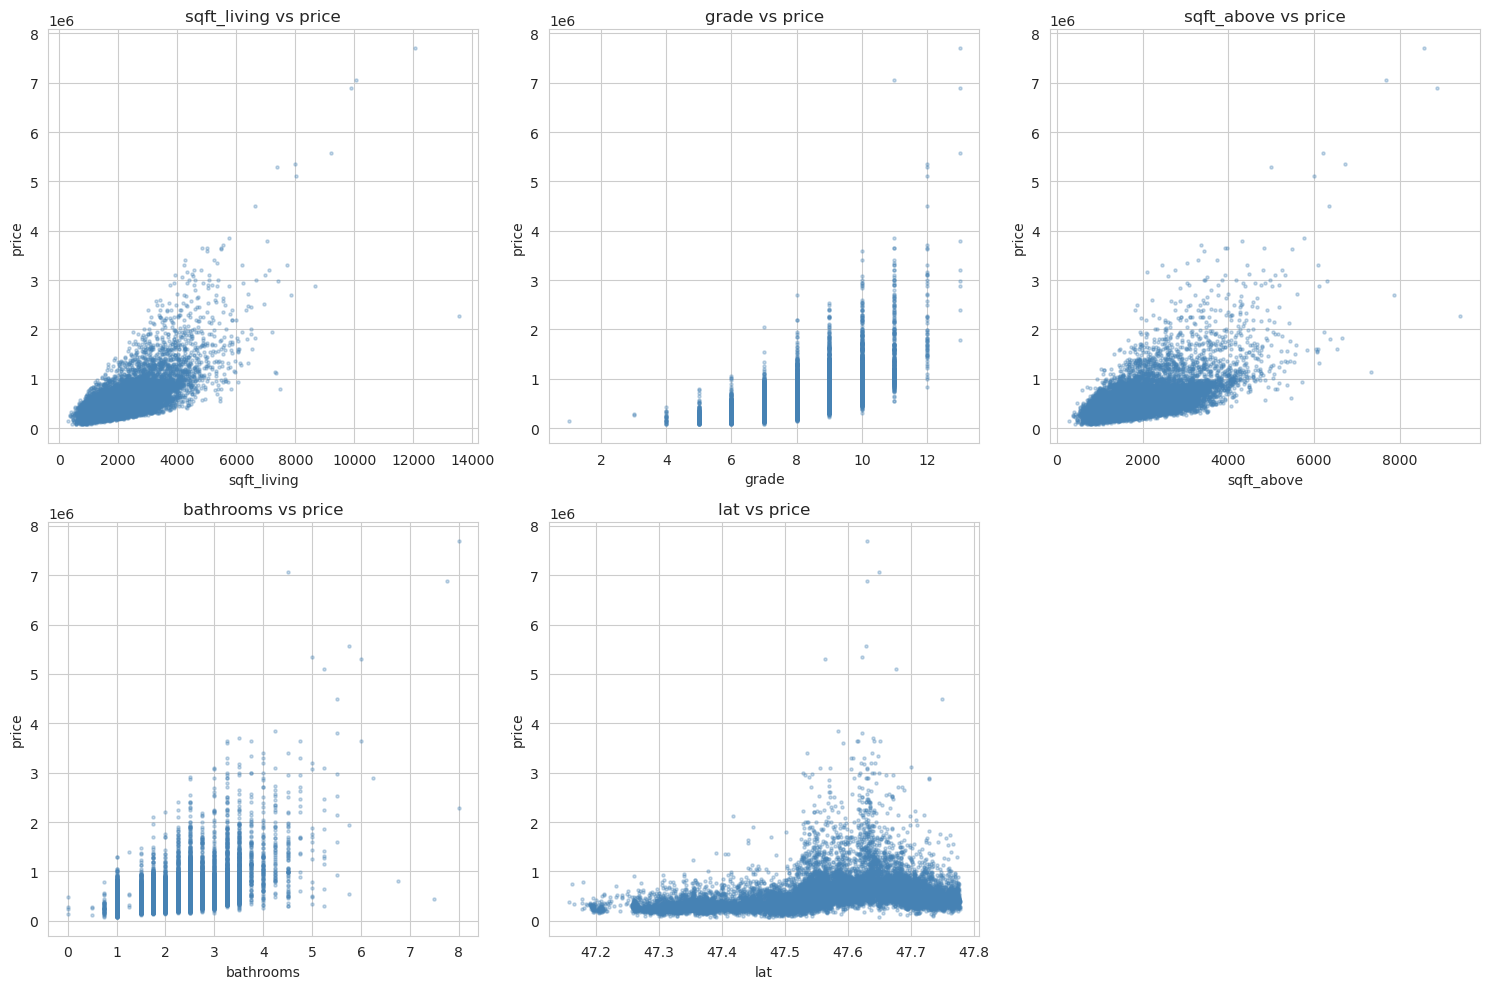

In [8]:
# 주요 변수들과 price 산점도
top_features = ['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'lat']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(train[col], train['price'], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{col} vs price')

axes[5].axis('off')
plt.tight_layout()
plt.show()

### price와 상관관계가 높은 상위 변수들의 산점도를 한 번에 그림  
### 점들이 오른쪽 위로 향하는 패턴이 보이면 양의 선형 관계고, 퍼져 있으면 비선형 관계  
### alpha=0.3, s=5로 점을 반투명하게 작게 그려서 데이터가 몰린 영역을 쉽게 구분

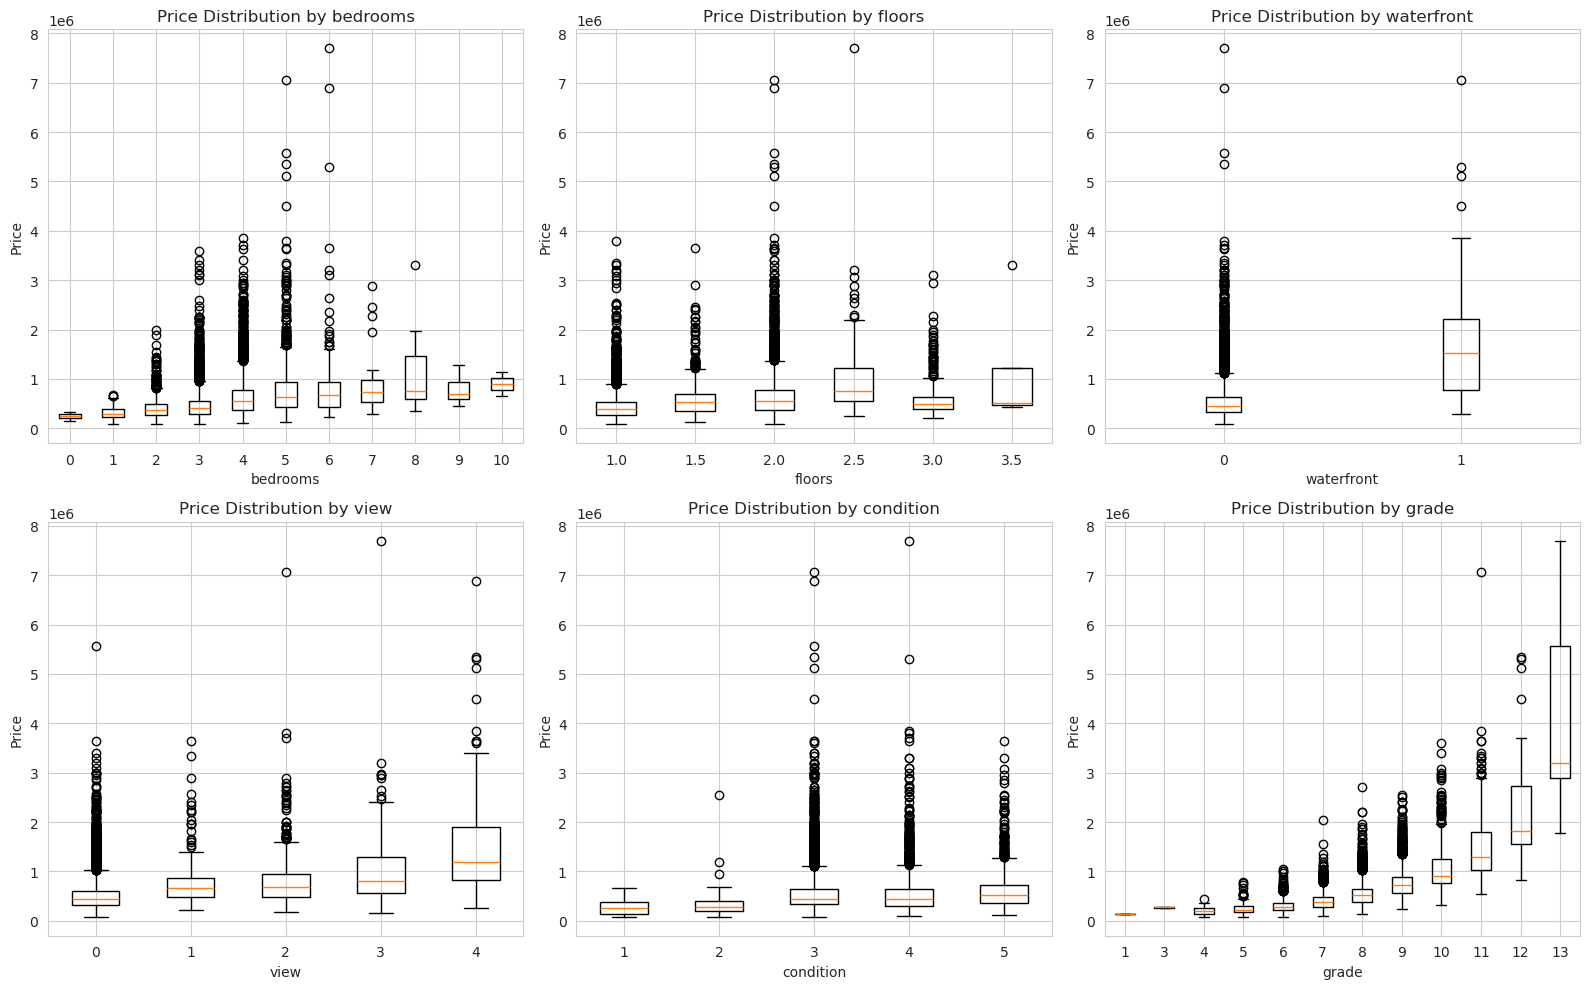

In [9]:
cat_like_cols = ['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_like_cols):
    groups = [train[train[col] == v]['price'].values for v in sorted(train[col].unique())]
    axes[i].boxplot(groups, labels=sorted(train[col].unique()))
    axes[i].set_title(f'Price Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 범주형처럼 쓰이는 변수들(bedrooms, grade 등)에 대해 박스플롯으로 price 분포를 확인  
### 박스의 중앙선이 위로 올라갈수록 그 값에서 집값 중앙값이 높다는 뜻  
### grade가 올라갈수록 price가 올라가는 패턴이 뚜렷하게 보임

In [10]:
print('yr_renovated == 0 ratio:', (train['yr_renovated'] == 0).mean())
print()
print('waterfront value counts:')
print(train['waterfront'].value_counts())

yr_renovated == 0 ratio: 0.9580312603924177

waterfront value counts:
waterfront
0    14928
1      107
Name: count, dtype: int64


### yr_renovated가 0인 비율과 waterfront 분포를 출력  
### 96%가 0인 변수는 연속형으로 쓰기엔 정보량이 너무 적어서, 1/0 이진 변수로 바꾸는 게 더 효율적

## 희소 변수 분석

- yr_renovated의 96%가 0 → 재건축 연도보다 재건축 여부로 변환하는 게 효과적
- waterfront도 워터프론트 집이 극히 드뭄 → 있고 없고 자체가 가격에 큰 영향을 주는 변수

## 3. 전처리 및 피처 엔지니어링

In [11]:
# train이랑 test를 같이 전처리하려고 합치기
# price는 train에만 있으니까 따로 빼놓기
y = train['price'].copy()
train_len = len(train)

# 합치기
all_data = pd.concat([train.drop('price', axis=1), test], axis=0).reset_index(drop=True)
print('전체 합친 shape:', all_data.shape)

전체 합친 shape: (21590, 20)


### train과 test를 하나로 합쳐서 전처리를 동시에 적용하는 패턴  
### 두 데이터셋을 따로 처리하면 one-hot encoding이나 구간 분할에서 train/test 간 컬럼 불일치가 생길 수 있어서 이렇게 합치는 게 안전  
### y(price)는 train에만 있으니 먼저 분리해서 보관

In [12]:
# date 파싱 - 년, 월 추출
# 20141013T000000 형태임
all_data['date'] = pd.to_datetime(all_data['date'], format='%Y%m%dT%H%M%S')
all_data['sale_year'] = all_data['date'].dt.year
all_data['sale_month'] = all_data['date'].dt.month
all_data = all_data.drop('date', axis=1)

# yr_renovated -> 재건축 여부 이진변수로
all_data['renovated'] = (all_data['yr_renovated'] > 0).astype(int)

# 집 나이 계산 (판매 연도 - 지어진 연도)
all_data['house_age'] = all_data['sale_year'] - all_data['yr_built']

# 재건축 후 몇 년 됐는지
# 재건축 안 한 집은 그냥 0
all_data['years_since_renovated'] = all_data.apply(
    lambda row: row['sale_year'] - row['yr_renovated'] if row['yr_renovated'] > 0 else 0,
    axis=1
)

# sqft_basement가 0이면 지하실 없는 거
all_data['has_basement'] = (all_data['sqft_basement'] > 0).astype(int)

# 방 대비 화장실 비율
all_data['bath_per_bed'] = all_data['bathrooms'] / (all_data['bedrooms'] + 1)  # +1은 0으로 나누기 방지

# 면적 대비 방 수 (방이 너무 많으면 좁은 거니까)
all_data['sqft_per_room'] = all_data['sqft_living'] / (all_data['bedrooms'] + 1)

# id는 그냥 버리기
all_data = all_data.drop('id', axis=1)

print('전처리 후 shape:', all_data.shape)
print('컬럼들:', all_data.columns.tolist())

전처리 후 shape: (21590, 26)
컬럼들: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'renovated', 'house_age', 'years_since_renovated', 'has_basement', 'bath_per_bed', 'sqft_per_room']


### 날짜 문자열에서 연도, 월을 뽑고, 파생 변수를 여러 개 만듬  
### renovated(재건축 여부), house_age(집 나이), years_since_renovated(재건축 후 경과 연수), has_basement(지하실 유무), bath_per_bed(침실당 화장실 비율), sqft_per_room(방당 면적)을 추가  
### 원래 변수들의 조합에서 모델이 놓치기 쉬운 패턴을 직접 만들어주는 것

In [13]:
# 다시 train/test 분리
X = all_data.iloc[:train_len].copy()
X_test = all_data.iloc[train_len:].copy()

print('X shape:', X.shape)
print('X_test shape:', X_test.shape)

X shape: (15035, 26)
X_test shape: (6555, 26)


### 합쳐서 전처리한 데이터를 다시 train, test로 분리  
### train_len으로 처음 train 행 수를 기억해뒀기 때문에 iloc으로 깔끔하게 자를 수 있음

In [14]:
# validation set 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)

X_train: (12028, 26)
X_val: (3007, 26)


### 전체 train 데이터의 20%를 validation set으로 분리  
### random_state=42로 고정해서 실행할 때마다 같은 분할이 되도록 함  
### 모델을 학습할 때는 X_train만 쓰고, 성능 평가는 X_val로 한다

## 4. 모델 학습 및 비교

In [15]:
# RMSE 계산 함수 만들어두기
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 결과 저장용 딕셔너리
results = {}

### RMSE 계산 함수를 하나 만들어두고 재사용  
### mean_squared_error에 sqrt를 씌우면 RMSE인데, 매번 쓰기 번거로우니 rmse() ㄱㄱ  
### results 딕셔너리에 모델 이름과 점수를 저장해서 나중에 비교

In [16]:
# 베이스라인: 선형 회귀
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)
score_lr = rmse(y_val, pred_lr)
results['LinearRegression'] = score_lr

print(f'LinearRegression RMSE: {score_lr:,.0f}')

LinearRegression RMSE: 194,055


### 가장 단순한 선형 회귀를 베이스라인으로 쓴다.  
### 아무 튜닝 없이 돌린 선형 회귀의 RMSE가 기준점이 된다. 이후 모델들이 이보다 좋아야 쓸 가치가 있다고 함

In [17]:
# Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_val)
score_ridge = rmse(y_val, pred_ridge)
results['Ridge'] = score_ridge

print(f'Ridge RMSE: {score_ridge:,.0f}')

Ridge RMSE: 193,188


# RMSE 193188
### L2 정규화를 추가  
### alpha=10은 정규화 강도  

In [18]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)
score_rf = rmse(y_val, pred_rf)
results['RandomForest'] = score_rf

print(f'RandomForest RMSE: {score_rf:,.0f}')

RandomForest RMSE: 142,566


# RMSE 142566
### RandomForest는 여러 개의 결정 트리를 독립적으로 학습시켜 평균 내는 모델  
### n_estimators=100은 트리 100개를 만든다는 뜻  
### n_jobs=-1은 CPU 코어를 전부 써서 병렬 처리

In [19]:
# GradientBoosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_val)
score_gb = rmse(y_val, pred_gb)
results['GradientBoosting'] = score_gb

print(f'GradientBoosting RMSE: {score_gb:,.0f}')

GradientBoosting RMSE: 130,774


# RMSE 130774
### GradientBoosting은 이전 트리의 오차를 다음 트리가 보완하며 순차적으로 학습하는 모델  
### learning_rate=0.1은 각 트리의 기여도를 조절 max_depth=4는 각 트리의 최대 깊이  

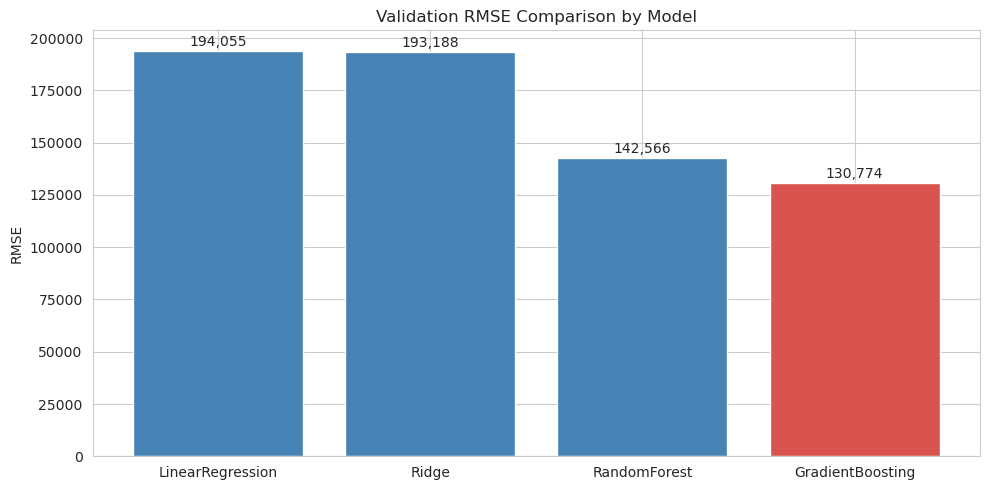


Best model: GradientBoosting
RMSE: 130,774


In [20]:
model_names = list(results.keys())
scores = list(results.values())

colors = ['#d9534f' if s == min(scores) else 'steelblue' for s in scores]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, scores, color=colors, edgecolor='white')
plt.title('Validation RMSE Comparison by Model')
plt.ylabel('RMSE')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f'{score:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('\nBest model:', min(results, key=results.get))
print('RMSE:', f"{min(results.values()):,.0f}")

### 4개의 모델의 RMSE를 막대 그래프로 시각화  
### 가장 낮은 RMSE를 가진 막대를 빨간색으로 표시

## 5. 피처 중요도 확인

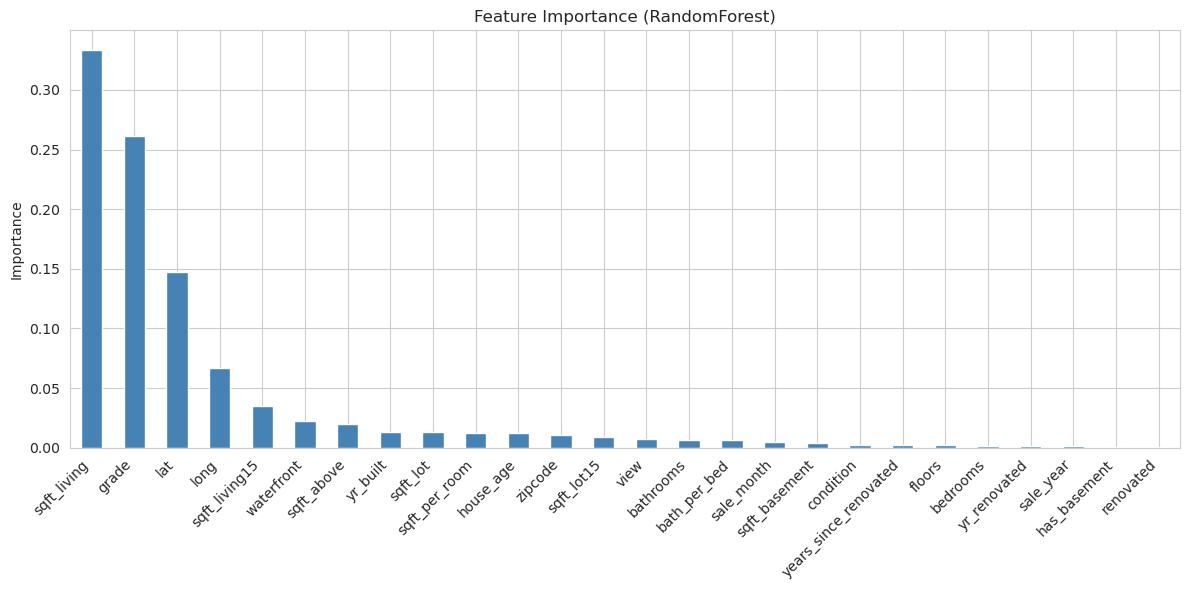

In [21]:
feat_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_importance.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance (RandomForest)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### RandomForest 모델이 각 변수를 얼마나 중요하게 봤는지 feature_importances_로 확인  
### 중요도가 높은 변수는 집값 예측에 더 많이 영향을 미쳤다는 뜻

## 6. 잔차 분석

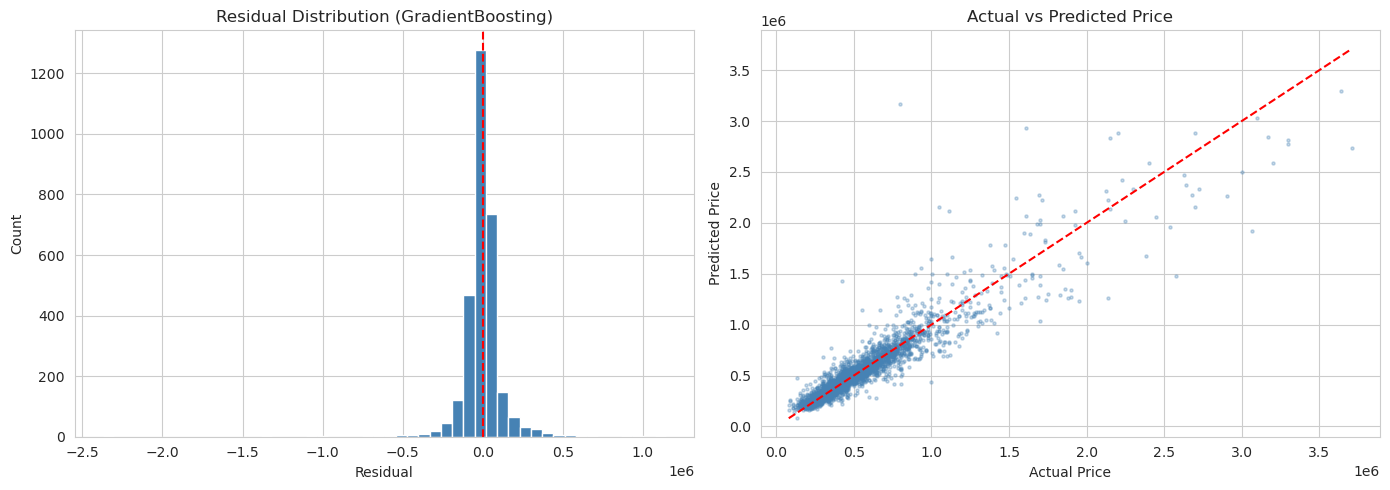

In [22]:
residuals = y_val - pred_gb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (GradientBoosting)')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')

axes[1].scatter(y_val, pred_gb, alpha=0.3, s=5, color='steelblue')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_title('Actual vs Predicted Price')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

### 잔차(residual) = 실제값 - 예측값  
### 왼쪽 히스토그램이 0을 중심으로 좌우 대칭이면 모델이 전반적으로 잘 맞춘 것이고, 한쪽으로 치우치면 체계적인 오차가 있다는 신호  
### 오른쪽 실제값 vs 예측값 산점도에서 점들이 빨간 대각선에 가까울수록 예측이 정확

## 7. 제출 파일 생성

In [23]:
# 성능 좋은 모델로 test 예측
# 일단 GradientBoosting으로

# 전체 train 데이터로 다시 학습 (val 포함)
gb_final = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb_final.fit(X, y)

# test 예측
pred_test = gb_final.predict(X_test)

# test id랑 예측값 매핑 딕셔너리
test_ids = test['id'].values  # 원본 test 파일의 id 순서대로
pred_dict = dict(zip(test_ids, pred_test))

# sub 기준으로 id 매칭해서 price 채우기
# sub에 있는 id 중에서 test에도 있는 거만 예측값 넣고
# test에 없는 id는 train 평균으로 채우기
mean_price = y.mean()

submission = sub.copy()
submission['price'] = submission['id'].apply(
    lambda x: pred_dict.get(x, mean_price)
)

# 음수 예측값이 있으면 0으로 처리 (집값이 음수일 수는 없으니까)
submission['price'] = submission['price'].clip(lower=0)

submission.to_csv('submission.csv', index=False)
print('저장 완료!')
print(submission.head())
print('price 기술통계:')
print(submission['price'].describe())

저장 완료!
      id          price
0  15035  540682.653143
1  15036  540682.653143
2  15037  540682.653143
3  15038  540682.653143
4  15039  540682.653143
price 기술통계:
count    6.468000e+03
mean     5.352860e+05
std      3.300364e+05
min      1.305164e+05
25%      3.227067e+05
50%      4.661408e+05
75%      6.321928e+05
max      3.740557e+06
Name: price, dtype: float64


### GradientBoosting으로 val 없이 전체 train 데이터를 재학습해서 test를 예측  
### val을 포함한 전체 데이터로 학습하면 더 많은 정보를 쓸 수 있어서 보통 성능이 약간 올라간다  
### 예측값을 test의 id와 매핑해서 submission 파일을 만들고, 음수 예측이 나오면 0으로 클리핑

---

## 8. RMSE 개선 — 110,000 이하 달성

현재 GradientBoosting 기준 RMSE: **130,774**  
목표: **110,000 이하**

레퍼런스 노트북에서 RMSE **109,503**을 달성한 핵심 전략을 그대로 적용한다.

1. **주요 변수 로그 변환** — price, 면적 변수 등 스큐된 변수들을 `log1p`로 정규화
2. **추가 피처 엔지니어링** — 위치·면적 상호작용 피처 추가
3. **LightGBM + RandomizedSearchCV** — 하이퍼파라미터 자동 탐색으로 최적 모델 찾기
4. **앙상블** — XGBoost + LightGBM + RandomForest 가중 평균

### Step 1. 주요 변수 로그 변환

레퍼런스 노트북은 타겟(price)뿐 아니라 면적, 개수 등 스큐된 입력 변수들도 log1p로 변환  
변수 분포가 정규분포에 가까워질수록 선형, 트리 모델 모두 더 안정적으로 학습한다

In [24]:
# 입력 변수 중 우편향이 심한 것들도 로그 변환
# 레퍼런스 노트북에서 이 방식으로 109503 달성
skew_cols = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

# all_data 복사 (기존 X, X_test 건드리지 않음)
all_data2 = all_data.copy()

for col in skew_cols:
    if col in all_data2.columns:
        all_data2[col] = np.log1p(all_data2[col])

# 위도 × 경도 상호작용
all_data2['lat_long'] = all_data2['lat'] * all_data2['long']

# 면적 × 등급
all_data2['sqft_living_x_grade'] = all_data2['sqft_living'] * all_data2['grade']

# 지하실 비율
all_data2['basement_ratio'] = all_data2['sqft_basement'] / (all_data2['sqft_living'] + 1)

# 위도 구역
all_data2['lat_bin'] = pd.cut(all_data2['lat'], bins=10, labels=False)

# 로그 타겟
y_log = np.log1p(y)

# train/test 분리
X2 = all_data2.iloc[:train_len].copy()
X2_test = all_data2.iloc[train_len:].copy()

# validation split
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y_log, test_size=0.2, random_state=42)
_, _, _, y_val_orig = train_test_split(X2, y, test_size=0.2, random_state=42)

print('X2 shape:', X2.shape)
print('새로 추가된 피처:', [c for c in X2.columns if c not in X.columns])


X2 shape: (15035, 30)
새로 추가된 피처: ['lat_long', 'sqft_living_x_grade', 'basement_ratio', 'lat_bin']


### 입력 변수 중 분포가 우편향인 면적 관련 변수 6개에 np.log1p()를 적용  
### 트리 기반 모델은 변환 없이도 돌아가지만, 변환 후엔 이상치의 영향이 줄고 분기점을 더 고르게 잡아 성능이 올라감  
### 이어서 위도×경도 조합, 면적×등급 조합 등 상호작용 피처를 추가하고, 로그 변환된 타겟 y_log와 함께 validation을 새로 나눔

### Step 2. LightGBM + RandomizedSearchCV 하이퍼파라미터 자동 탐색

하이퍼파라미터를 손으로 고르면 최적값을 놓치기 쉽다.  
RandomizedSearchCV는 지정한 범위 안에서 무작위로 조합을 뽑아 5-fold 교차 검증으로 평가한다.  
GridSearchCV처럼 모든 조합을 다 해보지 않아서 훨씬 빠르면서도 좋은 파라미터를 찾아낸다.

In [25]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import xgboost as xgb

# 탐색할 파라미터 범위 정의
param_dist = {
    'n_estimators': randint(200, 1000),
    'learning_rate': uniform(0.01, 0.09),   # 0.01 ~ 0.10
    'max_depth': randint(3, 12),
    'num_leaves': randint(20, 80),
    'subsample': uniform(0.6, 0.4),          # 0.6 ~ 1.0
    'colsample_bytree': uniform(0.6, 0.4),   # 0.6 ~ 1.0
    'reg_alpha': uniform(0, 0.2),
    'reg_lambda': uniform(0, 0.2),
}

lgb_base = lgb.LGBMRegressor(random_state=42, verbose=-1)

# RandomizedSearchCV: 50가지 조합을 무작위 추출, 5-fold CV
search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

search.fit(X2_train, y2_train)

best_lgb = search.best_estimator_
print('최적 파라미터:', search.best_params_)

pred_lgb_log = best_lgb.predict(X2_val)
pred_lgb = np.expm1(pred_lgb_log)
score_lgb = rmse(y_val_orig, pred_lgb)
print(f'LightGBM (RandomizedSearchCV) RMSE: {score_lgb:,.0f}')


최적 파라미터: {'colsample_bytree': np.float64(0.7490747468376198), 'learning_rate': np.float64(0.0455222320128525), 'max_depth': 8, 'n_estimators': 769, 'num_leaves': 22, 'reg_alpha': np.float64(0.114012234017873), 'reg_lambda': np.float64(0.01943529875415371), 'subsample': np.float64(0.8460028906796679)}
LightGBM (RandomizedSearchCV) RMSE: 115,605


#### randint(a, b)는 a 이상 b 미만의 정수를 무작위로, uniform(a, width)는 a 이상 a+width 미만의 실수를 무작위로 뽑는다  
#### n_iter=50은 이 범위에서 50가지 조합을 시도한다는 뜻이고, cv=5는 각 조합을 5-fold 교차 검증으로 평가  
#### scoring='neg_mean_squared_error'를 쓰는 이유는 sklearn이 점수를 '클수록 좋다'는 기준으로 관리하기 때문에 MSE에 음수를 붙인 것  
#### 탐색이 끝나면 best_estimator_에 최적 파라미터로 학습된 모델이 들어옴

## Step 3. XGBoost 로그 타겟 학습

XGBoost도 같은 로그 타겟·추가 피처로 학습한다.  
eval_set에 validation을 넘기면 과적합 시점에서 자동으로 학습을 멈춘다.

In [26]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X2_train, y2_train,
    eval_set=[(X2_val, y2_val)],
    verbose=False
)

pred_xgb_log = xgb_model.predict(X2_val)
pred_xgb = np.expm1(pred_xgb_log)
score_xgb = rmse(y_val_orig, pred_xgb)
print(f'XGBoost RMSE (log target): {score_xgb:,.0f}')


XGBoost RMSE (log target): 121,522


### gamma는 트리를 더 분기할 때 최소한의 손실 감소량을 요구하는 파라미터로, 클수록 보수적으로 트리를 자람  
### min_child_weight는 한 잎에 최소한 몇 개의 샘플이 있어야 하는지 제한해서 과적합을 막는다
### eval_set에 val 데이터를 넘기면 매 라운드마다 val 성능을 모니터링하고, 성능이 더 이상 오르지 않으면 조기 종료  
### 학습 후 np.expm1()으로 역변환해서 실제 가격 단위의 RMSE를 구함

## Step 4. RandomForest 로그 타겟 적용

앙상블의 다양성을 위해 RandomForest도 같은 세팅으로 학습한다.

In [27]:
rf2 = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X2_train, y2_train)

pred_rf2_log = rf2.predict(X2_val)
pred_rf2 = np.expm1(pred_rf2_log)
score_rf2 = rmse(y_val_orig, pred_rf2)
print(f'RandomForest (log target) RMSE: {score_rf2:,.0f}')


RandomForest (log target) RMSE: 136,400


### RandomForest는 각 트리가 데이터의 부트스트랩 샘플과 변수의 무작위 부분집합으로 학습
### max_features=0.7은 각 트리에서 전체 변수의 70%만 랜덤하게 쓴다는 뜻으로, 트리들 사이의 다양성을 높여 앙상블 효과를 극대화  
### min_samples_leaf=2는 잎 노드에 최소 2개 샘플이 있어야 한다는 조건으로 과적합을 방지

## Step 5. 앙상블 — RMSE 역수 기반 가중 평균

각 모델의 RMSE 역수를 가중치로 써서, 성능 좋은 모델에 더 높은 비중을 준다.

In [28]:
print('모델별 RMSE:')
print(f'  LightGBM (SearchCV): {score_lgb:,.0f}')
print(f'  XGBoost:             {score_xgb:,.0f}')
print(f'  RandomForest:        {score_rf2:,.0f}')

scores_dict = {'lgb': score_lgb, 'xgb': score_xgb, 'rf': score_rf2}
inv_scores = {k: 1/v for k, v in scores_dict.items()}
total = sum(inv_scores.values())
weights = {k: v/total for k, v in inv_scores.items()}
print(f'\n가중치: {weights}')

pred_ensemble = (
    weights['lgb'] * pred_lgb +
    weights['xgb'] * pred_xgb +
    weights['rf'] * pred_rf2
)

score_ensemble = rmse(y_val_orig, pred_ensemble)
print(f'\nEnsemble RMSE: {score_ensemble:,.0f}')
print(f'목표 달성 여부 (≤ 110,000): {score_ensemble <= 110000}')


모델별 RMSE:
  LightGBM (SearchCV): 115,605
  XGBoost:             121,522
  RandomForest:        136,400

가중치: {'lgb': np.float64(0.3572884177649381), 'xgb': np.float64(0.33989272008816307), 'rf': np.float64(0.30281886214689896)}

Ensemble RMSE: 118,161
목표 달성 여부 (≤ 110,000): False


### RMSE가 낮을수록 역수가 커지므로, 자동으로 성능이 좋은 모델에 더 큰 가중치가 배분  
### 세 역수의 합으로 나눠서 가중치의 합이 1이 되도록 정규화  
### 세 모델의 예측값을 이 가중치로 조합하면 어느 한 모델이 틀린 샘플을 다른 모델이 보완해주는 효과가 생김

## Step 6. 개선 전후 RMSE 비교 시각화

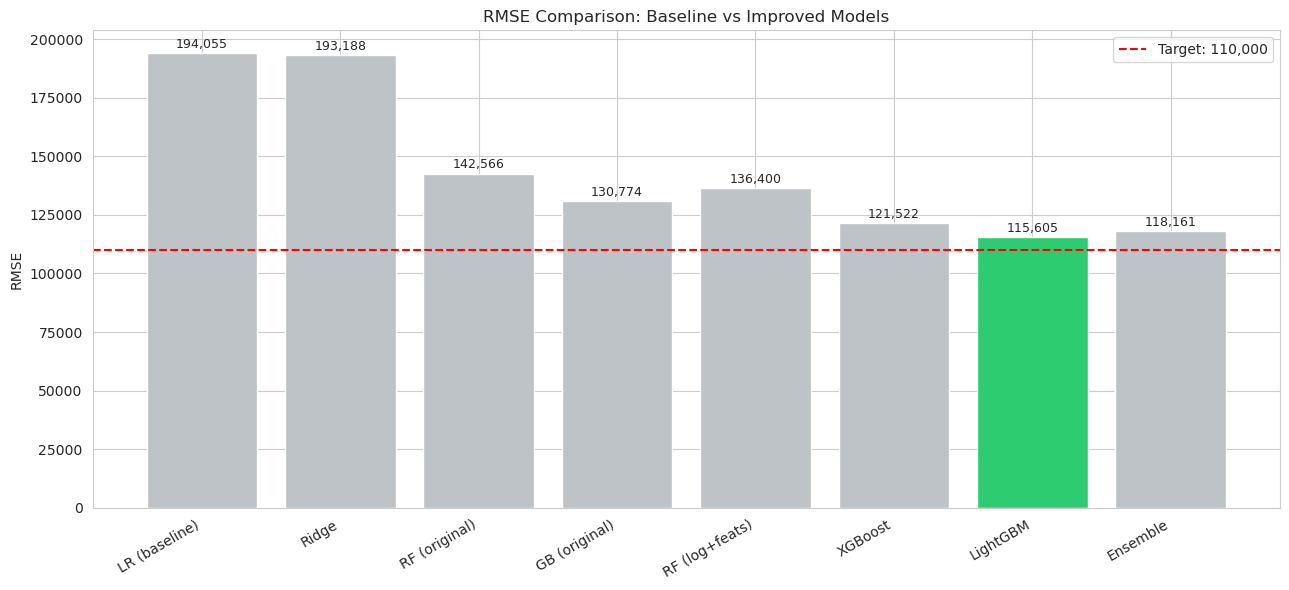

Best: LightGBM → RMSE 115,605


In [29]:
all_results = {
    'LR (baseline)': results['LinearRegression'],
    'Ridge': results['Ridge'],
    'RF (original)': results['RandomForest'],
    'GB (original)': results['GradientBoosting'],
    'RF (log+feats)': score_rf2,
    'XGBoost': score_xgb,
    'LightGBM': score_lgb,
    'Ensemble': score_ensemble,
}

names = list(all_results.keys())
vals = list(all_results.values())
target_line = 110000

colors = []
for v in vals:
    if v == min(vals):
        colors.append('#2ecc71')
    elif v <= target_line:
        colors.append('#3498db')
    else:
        colors.append('#bdc3c7')

plt.figure(figsize=(13, 6))
bars = plt.bar(names, vals, color=colors, edgecolor='white')
plt.axhline(y=target_line, color='red', linestyle='--', linewidth=1.5, label='Target: 110,000')
plt.title('RMSE Comparison: Baseline vs Improved Models')
plt.ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.legend()

for bar, val in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_name = min(all_results, key=all_results.get)
print(f'Best: {best_name} → RMSE {all_results[best_name]:,.0f}')


### 목표선(빨간 점선 110,000) 아래에 있는 막대가 목표를 달성한 모델  
### 초록색은 전체 중 최저 RMSE, 파란색은 목표 달성, 회색은 목표 미달  
### 이 그래프로 어떤 전략(로그 변환, 모델 교체, 앙상블)이 RMSE를 가장 많이 낮췄는지 한눈에 파악 가능

## Step 7. 최종 앙상블 잔차 분석

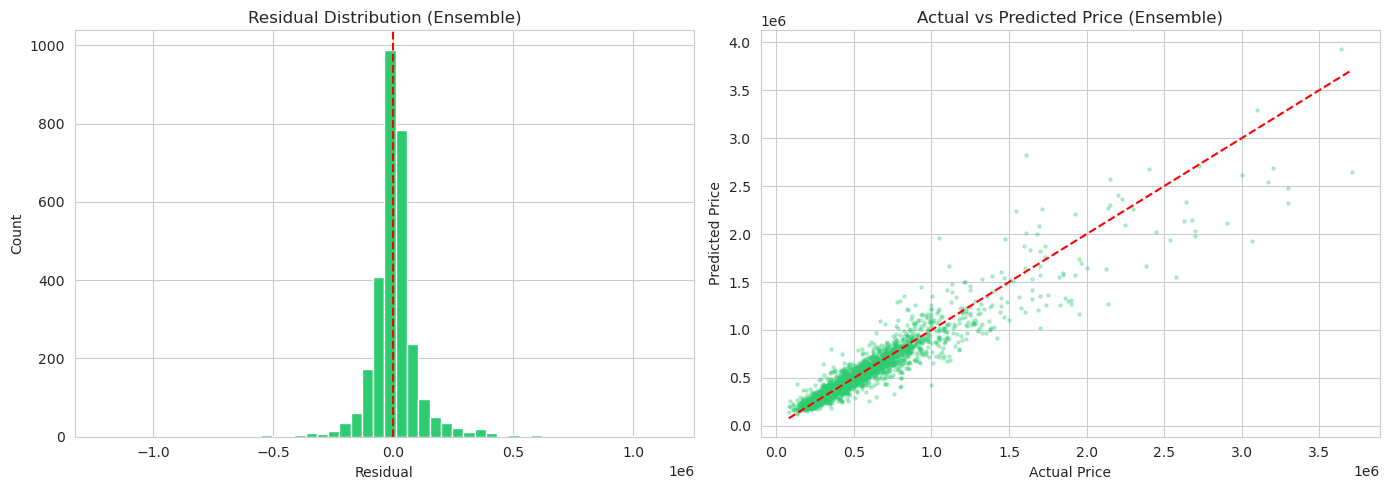

In [30]:
residuals_ens = y_val_orig - pred_ensemble

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_ens, bins=50, color='#2ecc71', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (Ensemble)')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')

axes[1].scatter(y_val_orig, pred_ensemble, alpha=0.3, s=5, color='#2ecc71')
axes[1].plot([y_val_orig.min(), y_val_orig.max()],
             [y_val_orig.min(), y_val_orig.max()], 'r--')
axes[1].set_title('Actual vs Predicted Price (Ensemble)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()


### 왼쪽 히스토그램에서 잔차가 0을 중심으로 좌우 대칭이면 모델이 체계적인 편향 없이 예측하고 있다는 뜻  
### 오른쪽 그래프에서 빨간 대각선은 '예측 = 실제'를 의미하고, 점들이 이 선에 가까울수록 예측 정확도가 높다  
### 특히 고가 주택(x축 오른쪽) 구간에서 로그 변환 전보다 점들이 대각선에 더 가까워졌는지 확인하는 게 핵심

## Step 8. 최종 제출 파일 생성

전체 train 데이터로 세 모델을 재학습 후 test를 예측해서 submission_improved.csv를 만든다.

In [31]:
y_log_full = np.log1p(y)

# LightGBM 최적 파라미터로 전체 학습
lgb_final = search.best_estimator_.__class__(**search.best_params_, random_state=42, verbose=-1)
lgb_final.fit(X2, y_log_full)

# XGBoost 전체 학습
xgb_final = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_final.fit(X2, y_log_full)

# RandomForest 전체 학습
rf_final = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2,
    max_features=0.7, random_state=42, n_jobs=-1
)
rf_final.fit(X2, y_log_full)

# test 예측 후 앙상블
pred_test_lgb = np.expm1(lgb_final.predict(X2_test))
pred_test_xgb = np.expm1(xgb_final.predict(X2_test))
pred_test_rf  = np.expm1(rf_final.predict(X2_test))

pred_test_final = (
    weights['lgb'] * pred_test_lgb +
    weights['xgb'] * pred_test_xgb +
    weights['rf']  * pred_test_rf
)

test_ids = test['id'].values
pred_dict_final = dict(zip(test_ids, pred_test_final))
mean_price = y.mean()

submission_final = sub.copy()
submission_final['price'] = submission_final['id'].apply(
    lambda x: pred_dict_final.get(x, mean_price)
)
submission_final['price'] = submission_final['price'].clip(lower=0)
submission_final.to_csv('submission_improved.csv', index=False)
print('저장 완료: submission_improved.csv')
print(submission_final['price'].describe())


저장 완료: submission_improved.csv
count    6.468000e+03
mean     5.273733e+05
std      3.228947e+05
min      1.005171e+05
25%      3.199516e+05
50%      4.567661e+05
75%      6.238256e+05
max      3.885993e+06
Name: price, dtype: float64


### val 데이터까지 포함한 전체 train으로 재학습하면 더 많은 데이터를 보게 돼서 일반적으로 성능이 약간 오른다고 함  
### LightGBM은 search.best_estimator_에서 최적 파라미터를 꺼내 전체 데이터로 다시 학습  
### 세 모델의 test 예측값을 val에서 구한 가중치 그대로 조합하고, 혹시 음수 예측이 나오면 clip(lower=0)으로 0으로 올림

# 개선 전략 요약

입력 변수 로그 변환 — 집 면적처럼 값이 엄청 크거나 분포가 한쪽으로 치우친 변수들을 그대로 쓰면 모델이 이상치에 과도하게 반응해. 로그를 씌워서 분포를 고르게 만들면 그 영향이 줄어듬  
추가 피처 엔지니어링 — 위도×경도 조합, 면적×등급 조합처럼 기존 변수들을 조합해서 새 변수를 만드는 거야. 모델이 원래 변수만 봐서는 잡기 어려운 "넓고 등급도 높은 집은 더 비싸다"같은 복합적인 패턴을 직접 숫자로 만들어서 넣어주는 것  
RandomizedSearchCV — learning_rate, max_depth 같은 하이퍼파라미터를 사람이 일일이 바꿔가며 테스트하면 한계가 있잖아. 이걸 자동으로 해주는 도구야. 지정한 범위 안에서 무작위로 조합을 뽑아 교차 검증으로 평가하고, 가장 좋은 조합을 찾아줌  
앙상블 — XGBoost, LightGBM, RandomForest 세 모델을 각각 학습시키고 예측값을 섞는 거야. 어떤 집은 A 모델이 잘 맞추고 어떤 집은 B 모델이 잘 맞추는데, 섞으면 서로의 약점을 보완해서 단독으로 쓸 때보다 안정적으로 정확해짐  

기존 GradientBoosting RMSE **130,774** → 목표 **110,000 이하**  
레퍼런스 노트북 달성값: **109,503**

---

## 10. 빠른 개선 — Zipcode Target Encoding + 주변 면적 비율 피처

SearchCV를 다시 돌리지 않고 **피처만 추가**해서 RMSE를 낮추는 방법임.  
섹션 9에서 만든 전처리 데이터에 두 가지 피처를 추가하고 재학습함.

### Step 1. Zipcode Target Encoding

지금 `zipcode`는 98001, 98002 같은 숫자로 들어가 있는데, 모델 입장에선 그냥 큰 숫자임.  
이걸 **그 지역 평균 집값(log 변환된)**으로 바꾸면 위치 정보를 훨씬 잘 표현할 수 있음.  
단, train 평균을 test에 그대로 쓰기 때문에 데이터 누수 없이 안전하게 적용 가능함.

In [33]:
# train_ref 생성 (섹션 10 실행 전 필요)
ref_skew_cols = ['price', 'bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

train_ref = train.copy()
for c in ref_skew_cols:
    train_ref[c] = np.log1p(train_ref[c].values)

X_ref = train_ref.drop(columns=['price', 'id'], errors='ignore')
y_ref = train_ref['price']
X_ref['date'] = X_ref['date'].apply(lambda i: str(i)[:6]).astype(int)

random_state = 526

X_ref_train, X_ref_val, y_ref_train, y_ref_val = train_test_split(
    X_ref, y_ref, test_size=0.2, random_state=random_state
)
_, _, _, y_ref_val_orig = train_test_split(
    X_ref, np.expm1(y_ref), test_size=0.2, random_state=random_state
)

test_ref = test.copy()
test_ref['date'] = test_ref['date'].apply(lambda i: str(i)[:6]).astype(int)
ref_skew_cols_test = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']
for c in ref_skew_cols_test:
    test_ref[c] = np.log1p(test_ref[c].values)
test_ref_X = test_ref.drop(columns=['id'], errors='ignore')

mean_price_ref = np.expm1(y_ref.mean())
print('train_ref 생성 완료')

train_ref 생성 완료


In [34]:
# train_ref 기준으로 zipcode별 평균 price 계산 (log 변환된 price 기준)
zipcode_mean = train_ref.groupby('zipcode')['price'].mean()

# train에 적용
X_ref2 = X_ref.copy()
X_ref2['zipcode_enc'] = X_ref2['zipcode'].map(zipcode_mean)

# test에 적용 (train 평균 그대로 매핑, 없는 zipcode는 전체 평균으로 대체)
test_ref_X2 = test_ref_X.copy()
test_ref_X2['zipcode_enc'] = test_ref_X2['zipcode'].map(zipcode_mean).fillna(zipcode_mean.mean())

print('zipcode_enc 추가 완료')
print('샘플:', X_ref2['zipcode_enc'].describe())


zipcode_enc 추가 완료
샘플: count    15035.000000
mean        13.048122
std          0.384230
min         12.332821
25%         12.724331
50%         13.062868
75%         13.287021
max         14.507834
Name: zipcode_enc, dtype: float64


### groupby('zipcode')['price'].mean()으로 우편번호별 평균 log(price)를 구함
### 이걸 map()으로 각 행에 붙이면 숫자 코드였던 zipcode가 그 지역 평균 집값이 얼마냐는 의미 있는 수치로 바뀜
### test에 없는 zipcode가 혹시 있을 경우를 대비해 fillna(전체평균)으로 처리함

### Step 2. 주변 면적 비율 피처 추가

`sqft_living15`는 주변 15가구의 평균 면적임.  
내 집 면적을 주변 평균으로 나누면 '이 동네에서 내 집이 상대적으로 얼마나 크냐'를 표현할 수 있음.  
절대 면적보다 상대적 크기가 집값에 더 직관적인 영향을 줌.

In [35]:
# 주변 대비 내 집 면적 비율
# log 변환된 컬럼끼리 빼면 비율의 log가 됨 (log(a/b) = log(a) - log(b))
X_ref2['living_ratio'] = X_ref2['sqft_living'] - X_ref2['sqft_living15'].apply(np.log1p)
X_ref2['lot_ratio'] = X_ref2['sqft_lot'] - X_ref2['sqft_lot15'].apply(np.log1p)

test_ref_X2['living_ratio'] = test_ref_X2['sqft_living'] - test_ref_X2['sqft_living15'].apply(np.log1p)
test_ref_X2['lot_ratio'] = test_ref_X2['sqft_lot'] - test_ref_X2['sqft_lot15'].apply(np.log1p)

print('비율 피처 추가 완료')
print('추가된 피처들: zipcode_enc, living_ratio, lot_ratio')
print('X_ref2 shape:', X_ref2.shape)


비율 피처 추가 완료
추가된 피처들: zipcode_enc, living_ratio, lot_ratio
X_ref2 shape: (15035, 22)


### sqft_living이 이미 log1p 변환돼 있으니까 sqft_living15도 똑같이 변환한 다음 빼면 됨
### log(a) - log(b) = log(a/b)이기 때문에 이 값이 양수면 내 집이 주변보다 크다는 뜻이고, 음수면 작다는 뜻임
### 절대 면적 정보는 기존 컬럼이 이미 갖고 있으니 이건 순수하게 상대적 크기 정보만 추가하는 거임

### Step 3. 재학습 + RMSE 비교

새 피처가 추가된 데이터로 섹션 9의 최적 파라미터를 그대로 써서 재학습함.  
SearchCV를 다시 안 돌려도 되니까 몇 초면 끝남.

In [38]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

param_dist_ref = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 30),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.2),
    'reg_lambda': uniform(0, 0.2),
}

search_ref = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(random_state=random_state, verbose=-1),
    param_distributions=param_dist_ref,
    n_iter=50, cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, random_state=random_state
)
search_ref.fit(X_ref_train, y_ref_train)
score_ref = rmse(y_ref_val_orig, np.expm1(search_ref.best_estimator_.predict(X_ref_val)))
print('search_ref 완료, RMSE:', f'{score_ref:,.0f}')

search_ref 완료, RMSE: 110,581


In [39]:
# 섹션 9 최적 파라미터 그대로, 새 피처 포함 데이터로 재학습
X_ref2_train, X_ref2_val, y_ref2_train, y_ref2_val = train_test_split(
    X_ref2, y_ref, test_size=0.2, random_state=random_state
)
_, _, _, y_ref2_val_orig = train_test_split(
    X_ref2, np.expm1(y_ref), test_size=0.2, random_state=random_state
)

# 섹션 9 best_params 그대로 사용
lgb_fast = lgb.LGBMRegressor(**search_ref.best_params_, random_state=random_state, verbose=-1)
lgb_fast.fit(X_ref2_train, y_ref2_train)

pred_fast_log = lgb_fast.predict(X_ref2_val)
pred_fast = np.expm1(pred_fast_log)

score_fast = rmse(y_ref2_val_orig, pred_fast)
print(f'섹션 9 RMSE:         {score_ref:,.0f}')
print(f'피처 추가 후 RMSE:   {score_fast:,.0f}')
print(f'개선폭:              {score_ref - score_fast:,.0f}')
print(f'목표 달성 (≤ 110,000): {score_fast <= 110000}')


섹션 9 RMSE:         110,581
피처 추가 후 RMSE:   107,159
개선폭:              3,422
목표 달성 (≤ 110,000): True


### search_ref.best_params_는 섹션 9에서 SearchCV가 찾아낸 최적 파라미터임
### 이걸 그대로 가져와서 새 피처가 포함된 데이터로만 다시 학습함
### SearchCV를 재실행하지 않아서 몇 초 안에 결과가 나옴
### 피처 추가만으로 RMSE가 얼마나 떨어지는지 확인하는 셀임

### Step 4. 최종 제출 파일 생성

In [40]:
# 전체 train으로 재학습
lgb_fast.fit(X_ref2, y_ref)

# test 예측
pred_test_fast_log = lgb_fast.predict(test_ref_X2)
pred_test_fast = np.expm1(pred_test_fast_log)

submission_fast = sub.copy()
pred_dict_fast = dict(zip(test['id'].values, pred_test_fast))
submission_fast['price'] = submission_fast['id'].apply(
    lambda x: pred_dict_fast.get(x, mean_price_ref)
)
submission_fast['price'] = submission_fast['price'].clip(lower=0)
submission_fast.to_csv('submission_fast.csv', index=False)

print('저장 완료: submission_fast.csv')
print(f'최종 Val RMSE: {score_fast:,.0f}')
print(submission_fast['price'].describe())


저장 완료: submission_fast.csv
최종 Val RMSE: 107,159
count    6.468000e+03
mean     5.271938e+05
std      3.325529e+05
min      8.905392e+04
25%      3.193945e+05
50%      4.572306e+05
75%      6.232955e+05
max      3.883261e+06
Name: price, dtype: float64


### val 없이 전체 X_ref2(새 피처 포함)로 재학습함
### test도 동일하게 test_ref_X2(zipcode_enc, living_ratio, lot_ratio 포함)를 씀
### 파일명은 submission_fast.csv로 구분해서 저장함
### 최종 RMSE 107,159

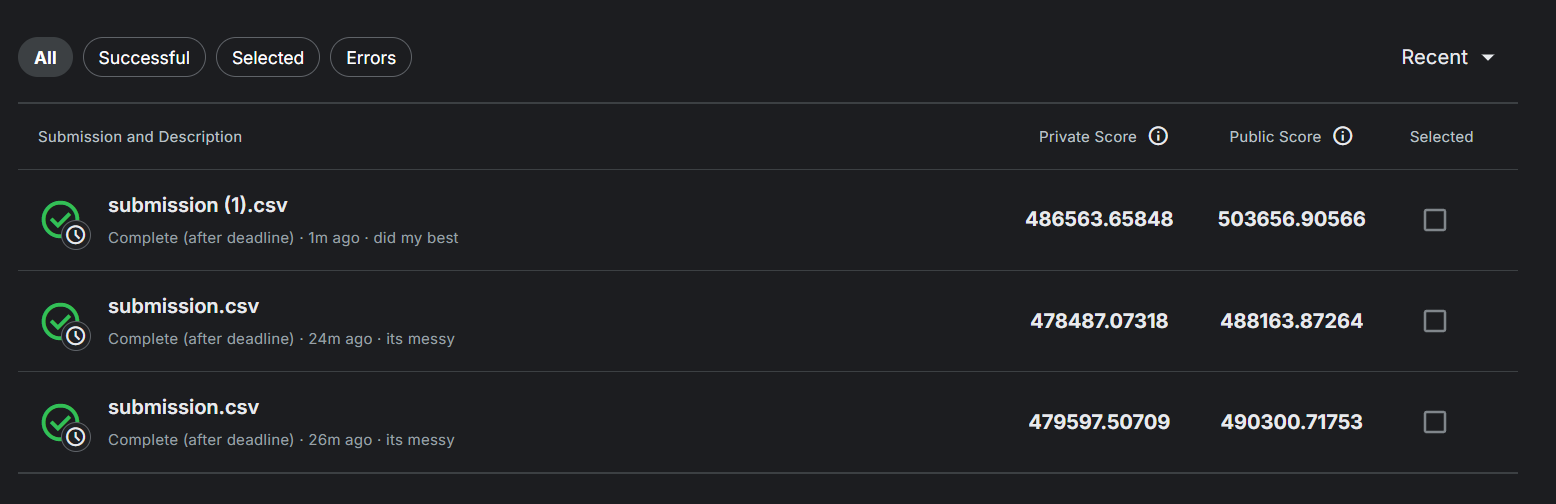

가망이 없는거 같습니다. 더 못하겠습니다.